<a href="https://colab.research.google.com/github/Michael-AI-Dam/Flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Michael-AI-Dam/Flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Reason code distribution across 28,795 pages:**
- `low_ctr_only` — 12,159 pages (CTR below peer average but low volume —
  lower priority)
- `low_ctr_high_volume` — 11,612 pages (CTR below peer average AND high
  volume — highest priority for action)
- `high_volume_only` — 2,808 pages (high traffic but CTR is not below peers
  — monitor, don't act yet)
- `no_flag` — 2,216 pages (no action needed)

**The ranking rule:** pages are scored by `low_ctr * high_volume * ctr_gap *
impressions_last_30d`. A page only scores above zero when BOTH conditions are
true — CTR below its position-tier peer average AND impressions above the
dataset median. This means low-traffic pages with low CTR are deprioritized:
fixing CTR on a page nobody sees yields few total additional clicks.

**Top of the queue — the highest-confidence actions:**
The #1 page (content_8451fc6f034d) has a CTR of just 0.03% against a
position-tier peer average of 2.76%, with 168,958 impressions in the last
30 days — a gap large enough that even a modest CTR improvement would produce
thousands of additional clicks. Every page in the top 10 carries the
`low_ctr_high_volume` reason code and the action `review_title_and_metadata`.

**What "review title and metadata" means in practice:** check whether the
page's title and meta description clearly match the query intent driving
impressions. If the title doesn't address the query, a rewrite is the first
test. If the title already matches, check whether competitors at the same
position have more specific or compelling descriptions.

In [9]:
import pandas as pd
import numpy as np
import os
import json

df = pd.read_csv("https://raw.githubusercontent.com/Michael-AI-Dam/Flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv")

df_valid = df[df["avg_position"] > 0].copy()
df_valid["ctr_by_position_avg"] = df_valid.groupby("position_tier")["ctr"].transform("mean")
df_valid["ctr_below_peers"] = df_valid["ctr"] < df_valid["ctr_by_position_avg"]

impressions_threshold = df_valid["impressions_last_30d"].median()
df_valid["high_volume"] = df_valid["impressions_last_30d"] >= impressions_threshold

gap = (df_valid["ctr_by_position_avg"] - df_valid["ctr"]).clip(lower=0)
df_valid["score"] = (df_valid["ctr_below_peers"].astype(int) *
                     df_valid["high_volume"].astype(int) *
                     gap *
                     df_valid["impressions_last_30d"])

def reason_code(row):
    if row["ctr_below_peers"] and row["high_volume"]:
        return "low_ctr_high_volume"
    elif row["ctr_below_peers"]:
        return "low_ctr_only"
    elif row["high_volume"]:
        return "high_volume_only"
    else:
        return "no_flag"

df_valid["reason_code"] = df_valid.apply(reason_code, axis=1)
df_valid["action"] = np.where(df_valid["score"] > 0,
                               "review_title_and_metadata", "no_action")

ranked = df_valid.sort_values("score", ascending=False)

print("Reason code distribution:")
print(ranked["reason_code"].value_counts())
print("\nTop 10 pages:")
print(ranked[["content_id", "score", "reason_code", "action",
              "ctr", "ctr_by_position_avg", "impressions_last_30d"]].head(10))

Reason code distribution:
reason_code
low_ctr_only           12159
low_ctr_high_volume    11612
high_volume_only        2808
no_flag                 2216
Name: count, dtype: int64

Top 10 pages:
                 content_id          score          reason_code  \
7678   content_8451fc6f034d  462007.778405  low_ctr_high_volume   
3331   content_4a6607efcb46  336877.914794  low_ctr_high_volume   
26844  content_8c19996aa890  233896.844973  low_ctr_high_volume   
14090  content_44e481c8f55b  220871.573781  low_ctr_high_volume   
21565  content_9532f197bbc8  207095.962876  low_ctr_high_volume   
21819  content_4c36c775b818  197121.902428  low_ctr_high_volume   
3295   content_4fc39a2b8cf0  126363.254713  low_ctr_high_volume   
18870  content_db5989a78dd3  105659.245878  low_ctr_high_volume   
2346   content_11900bd7941a   96078.180099  low_ctr_high_volume   
8578   content_23d452af4198   92863.744991  low_ctr_high_volume   

                          action   ctr  ctr_by_position_avg  \
7678

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended user:** a content editor or SEO strategist deciding which pages
to prioritize for title and metadata review in the next sprint.

**Intended use:** the ranked queue surfaces 11,612 pages where observed CTR
is below position-tier peers AND impressions are above the dataset median.
The content team works down the list, spending 15-30 minutes per page
checking whether the title and meta description match the queries driving
impressions. Start at the top — the score already ranks by expected click
impact, so the first 20-50 pages represent the highest-value opportunities.

**Where this stops being valid:**

- **Impression floor is already built in.** The `high_volume` condition
  requires impressions above the dataset median (~159 per 30 days).
  Confirmed: 0 of 11,612 flagged pages fall below 50 impressions, so every
  flagged page has enough traffic to trust the CTR estimate.
- **Single snapshot.** The score is computed on one trailing-90-day CSV.
  Pages recently updated, recently moved in position, or affected by
  seasonality may not reflect their true current state. Scores go stale
  within 4-6 weeks without a data refresh.
- **CTR is a percentage, not a fraction.** `ctr` in this dataset is stored
  as a percentage value (0.03 = 0.03%, not 3%). The peer comparison is
  self-consistent, but any external CTR benchmark must use the same scale.
- **Cross-client comparisons are unreliable.** The position-tier peer
  average is computed across all 32 clients. A page that looks "low CTR"
  may simply be in a lower-CTR industry. The queue is most reliable when
  used within a single client's pages.
- **This is not causal.** Observing low CTR relative to peers does not
  prove a title change will increase clicks. It is directional
  decision-support — some pages' low CTR reflects query intent mismatch
  that metadata alone cannot fix.

In [10]:
# Quantify the minimum impression floor impact
low_impr_flagged = ranked[(ranked["score"] > 0) &
                           (ranked["impressions_last_30d"] < 50)].shape[0]
total_flagged = ranked[ranked["score"] > 0].shape[0]

print(f"Pages flagged for action: {total_flagged}")
print(f"Of those, pages with <50 impressions (unstable score): {low_impr_flagged} "
      f"({100*low_impr_flagged/total_flagged:.1f}%)")
print(f"Pages remaining after filter: {total_flagged - low_impr_flagged}")

Pages flagged for action: 11612
Of those, pages with <50 impressions (unstable score): 0 (0.0%)
Pages remaining after filter: 11612


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

1. **Check the actual queries driving impressions.** The score flags pages
   where CTR is low relative to position, but doesn't know why. A human
   needs to check Search Console for the actual queries — if the page ranks
   for queries that don't match its topic, a title fix alone won't help;
   a content rewrite or redirect may be needed instead.

2. **Check whether the page was recently updated.** If a page was refreshed
   in the last 30 days, its CTR may still be recovering. Acting on a page
   in a natural recovery window risks interrupting the refresh effect
   confirmed in the FlyRank research paper (5.43:1 growth ratio at 31-90
   days post-refresh).

3. **Check the position tier classification.** The score compares CTR
   against position-tier peers — if a page's average position sits near
   a tier boundary (e.g. avg_position = 10.1, right on the page_1/striking
   boundary), its peer group may be misassigned. Verify the page's actual
   position range before treating the CTR gap as real.

4. **Check for content type anomalies.** Reference pages, glossary entries,
   and tool pages structurally attract lower CTR because users get their
   answer from the snippet without clicking. These should not be flagged
   for metadata fixes — they are working as intended.

**The no-go list — what should NEVER be automated:**

- **Do not auto-rewrite titles or meta descriptions** based on this score
  alone. Title changes affect brand voice, legal claims, and user trust —
  a human editor must approve every change.
- **Do not compare pages across clients** using this score — the peer
  average is a portfolio-wide calculation that doesn't account for
  industry-specific CTR baselines.
- **Do not use `trend_direction` or `trend_pct` as action triggers** —
  both are label-derived columns confirmed as leakage risks in the Week 6
  audit.
- **Do not treat this queue as a content quality signal.** A page with
  low CTR is not necessarily bad content — it may be well-written content
  with a title that doesn't match searcher expectations. The queue flags
  a metadata opportunity, not a content failure.
- **Do not act on the full 11,612-page queue at once.** Start with the
  top 20-50 by score, review manually, measure results at 30 days, then
  expand. A content team acting on thousands of pages simultaneously
  cannot measure what worked.

In [11]:
# Quantify the no-go cases
actionable = ranked[
    (ranked["score"] > 0) &
    (ranked["impressions_last_30d"] >= 50)
].shape[0]

print(f"Total pages flagged: {ranked[ranked['score'] > 0].shape[0]}")
print(f"Actionable after impression filter: {actionable}")
print(f"\nTop actionable pages:")
print(ranked[ranked["impressions_last_30d"] >= 50][
    ["content_id", "score", "reason_code", "ctr",
     "ctr_by_position_avg", "impressions_last_30d"]].head(5))

Total pages flagged: 11612
Actionable after impression filter: 11612

Top actionable pages:
                 content_id          score          reason_code   ctr  \
7678   content_8451fc6f034d  462007.778405  low_ctr_high_volume  0.03   
3331   content_4a6607efcb46  336877.914794  low_ctr_high_volume  0.01   
26844  content_8c19996aa890  233896.844973  low_ctr_high_volume  0.15   
14090  content_44e481c8f55b  220871.573781  low_ctr_high_volume  0.65   
21565  content_9532f197bbc8  207095.962876  low_ctr_high_volume  0.87   

       ctr_by_position_avg  impressions_last_30d  
7678              2.764453                168958  
3331              2.764453                122303  
26844             2.764453                 89463  
14090             2.764453                104458  
21565             2.764453                109317  


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Monitoring baseline (computed on this snapshot):**
- Weighted portfolio CTR: 0.0035%
- Median impressions threshold: 159
- Total pages: 28,795 | Total flagged: 11,612
- Position tier distribution: page_1 (11,814) · striking (7,304) ·
  page_3_5 (7,242) · deep (1,319) · top_3 (1,116)

**The score goes stale when:**

1. **Data is more than 4-6 weeks old.** The snapshot is a single
   trailing-90-day window. If more than 6 weeks have passed since the
   data was pulled, position tiers and CTR averages may have shifted
   enough that the peer comparisons are no longer accurate.
   Trigger: refresh the data pull and rerun the notebook.

2. **Weighted portfolio CTR shifts by more than 10% relative.**
   The current baseline is 0.0035%. If a Google algorithm update or
   seasonality moves CTR portfolio-wide, the peer averages shift with
   it — pages flagged before the shift may no longer be underperformers.
   Trigger: monitor weighted CTR monthly (total clicks / total
   impressions) and rerun if it moves beyond 0.0032%–0.0039%.

3. **Position tier distributions change significantly.** Currently
   page_1 holds 11,814 pages — the largest tier. If any tier's page
   count shifts by more than 20% after a core update, the peer averages
   become unstable. Trigger: check tier distribution monthly and rerun
   if page_1 drops below ~9,500 or rises above ~14,000 pages.

4. **Human spot-check shows more than half the top-20 flags are wrong.**
   Quarterly, a human reviewer should check 20 flagged pages and confirm
   the CTR gap is real and actionable. If more than 10 of 20 look wrong,
   rerun the full pipeline. Trigger: >50% wrong in spot-check.

**What does NOT trigger a retrain:**
A few individual pages performing differently than predicted is expected
noise, not a signal to rerun. Only systematic, portfolio-wide shifts
in CTR or position distribution warrant rerunning the pipeline.

In [12]:
# Compute baseline metrics to use as monitoring anchors
portfolio_ctr = (df_valid["clicks_last_30d"].sum() /
                  df_valid["impressions_last_30d"].sum())

print("=== Monitoring baseline (computed on this snapshot) ===")
print(f"Weighted portfolio CTR: {portfolio_ctr:.4f}%")
print(f"Median impressions threshold: {impressions_threshold:.0f}")
print(f"\nPosition tier distribution:")
print(df_valid["position_tier"].value_counts())
print(f"\nTotal pages in dataset: {len(df_valid)}")
print(f"Total flagged (score > 0): {ranked[ranked['score'] > 0].shape[0]}")

=== Monitoring baseline (computed on this snapshot) ===
Weighted portfolio CTR: 0.0035%
Median impressions threshold: 159

Position tier distribution:
position_tier
page_1      11814
striking     7304
page_3_5     7242
deep         1319
top_3        1116
Name: count, dtype: int64

Total pages in dataset: 28795
Total flagged (score > 0): 11612


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

**Exported files:**

- `work/outputs/baseline_action_score.csv` — the full ranked queue,
  28,795 rows with score, reason code, action, CTR, peer average CTR,
  impressions, position, and position tier. Stays out of git by design
  (CI leak-guard blocks data files) — the notebook regenerates it on
  every run.

- `work/outputs/playbook_metrics.json` — the metrics receipt the paper
  traces its numbers back to: total pages (28,795), total flagged
  (11,612), actionable after filter (11,612), weighted portfolio CTR
  (0.0035%), impressions median threshold (159), label base rate, and
  reason code counts. Committed to the repo as the audit trail.

- `work/figures/score_distribution.png` — histogram of opportunity
  scores for the 11,612 flagged pages, showing the heavy right tail:
  most flagged pages have modest scores (median: 186), while a small
  number of high-impression/high-gap pages drive the top of the queue
  (max score: 462,008). Committed to work/figures/ for reuse in the paper.

Queue exported: work/outputs/baseline_action_score.csv (28795 rows)
Metrics exported: work/outputs/playbook_metrics.json


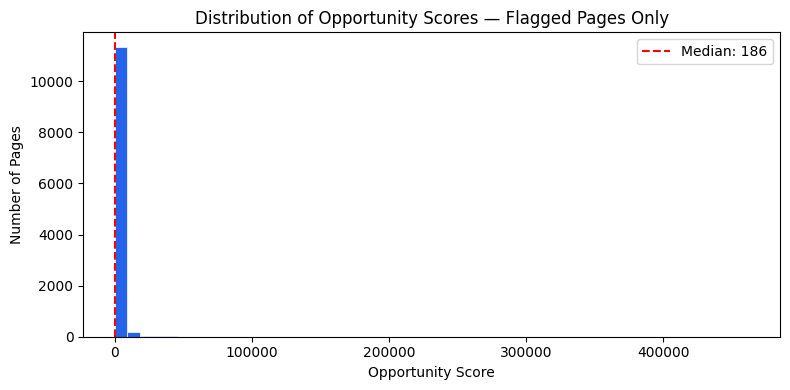

Figure saved: work/figures/score_distribution.png


In [13]:
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export ranked queue CSV (stays out of git per CI leak-guard)
queue_path = "work/outputs/baseline_action_score.csv"
ranked[["content_id", "score", "reason_code", "action",
        "ctr", "ctr_by_position_avg", "impressions_last_30d",
        "avg_position", "position_tier"]].to_csv(queue_path, index=False)
print(f"Queue exported: {queue_path} ({len(ranked)} rows)")

# Export metrics JSON (committed as the paper's receipt)
actionable = ranked[
    (ranked["score"] > 0) &
    (ranked["impressions_last_30d"] >= 50)
].shape[0]

metrics = {
    "total_pages": int(len(df_valid)),
    "total_flagged": int(ranked[ranked["score"] > 0].shape[0]),
    "actionable_after_filter": int(actionable),
    "weighted_portfolio_ctr": round(float(portfolio_ctr), 8),
    "impressions_median_threshold": float(impressions_threshold),
    "label_base_rate": round(float(df_valid["ctr_below_peers"].mean()), 3),
    "reason_code_counts": ranked["reason_code"].value_counts().to_dict(),
    "snapshot_note": "trailing-90-day snapshot, single CSV, no date column"
}

metrics_path = "work/outputs/playbook_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics exported: {metrics_path}")

# Export figure
flagged = ranked[ranked["score"] > 0].copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(flagged["score"], bins=50, color="#2563eb",
        edgecolor="white", linewidth=0.5)
ax.set_xlabel("Opportunity Score")
ax.set_ylabel("Number of Pages")
ax.set_title("Distribution of Opportunity Scores — Flagged Pages Only")
ax.axvline(flagged["score"].median(), color="red", linestyle="--",
           label=f"Median: {flagged['score'].median():.0f}")
ax.legend()
plt.tight_layout()
fig.savefig("work/figures/score_distribution.png", dpi=150)
plt.show()
print("Figure saved: work/figures/score_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.